# Project Name: Gradient Boosting Model - Home Credit Default Risk 
Eileen QIN Yuxuan, MMath Keble College, Oxford University

Target: Build a supervised machine learning pipeline to predict loan default risk using the Home 
Credit Default Risk Kaggle dataset (Data source: https://www.kaggle.com/c/home-credit-default-risk/data?utm_source=chatgpt.com ). The target is binary, and the main evaluation metric should be AUC.

    -Binary classification（二元分类）：Breaching of Contract? 0- False  1- True
    -AUC: ROC Curve:
        Horizontal axis: False positive rate (FPR)
        Vertical axis: True positive rate (TPR)

        AUC (Area Under Curve):
        The area under the ROC curve, measuring the model's ability to distinguish between positive and negative samples.
    -Feature engineering: Creating new variables (features) from raw data (i.e. from DoB to Age) to help the model learn patterns more effectively (Better features often improve performance more than choosing a different model.)
    -Missing‑Value Handling: Real datasets always have missing values. Models cannot train on NaNs, it's important to learn how to convert NaNs to reasonable values (i.e. replace NaN by median)
    -Categorical Encoding: convert category in strings to numbers, for better handling of ML models.

In [2]:
# Import and Configuration

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid", font_scale=1.1)

# For reproducibility
RANDOM_STATE = 42  # 机器学习界的一个“传统梗”，来自《银河系漫游指南》：42 是“生命、宇宙以及一切问题的终极答案”。
np.random.seed(RANDOM_STATE)

In [3]:
# Load the Home Credit Default Risk dataset downloaded from Kaggle, username: qineileen (google logon required)
DATA_DIR = "../data/home_credit_default_risk/"
train_path = os.path.join(DATA_DIR, "application_train.csv")
# Read the main training file
df = pd.read_csv(train_path)

print("Shape of raw training data:", df.shape)
print("Columns:", len(df.columns))
print(df[["TARGET"]].head())

Shape of raw training data: (307511, 122)
Columns: 122
   TARGET
0       1
1       0
2       0
3       0
4       0


In [4]:
# 3. Preprocessing helpers

TARGET_COL = "TARGET"

# Separate features and target
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Number of numeric features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))
print("Example categorical columns:", cat_cols[:10])

Number of numeric features: 105
Number of categorical features: 16
Example categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2804\2211429326.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [5]:
# Basic feature engineering: Fill missing values and encode categoricals
# 3. Preprocessing helpers
# do simple but robust feature engineering:
# Separate target and features
# Identify categorical vs numeric columns
# Handle missing values:
# Numeric: fill with median
# Categorical: fill with "Missing"
# Encode categoricals:
# For LightGBM/XGBoost: label encode
# For CatBoost: we’ll keep them as strings and pass categorical indices
# Apply LabelEncoder per column.
TARGET_COL = "TARGET"

# Separate features and target
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Number of numeric features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))
print("Example categorical columns:", cat_cols[:10])

Number of numeric features: 105
Number of categorical features: 16
Example categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2804\1519544638.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [7]:
# Missing‑value handling and encoding for LightGBM/XGBoost
# 4. Preprocess for LightGBM / XGBoost

X_lgb_xgb = X.copy()

# 4.1 Handle missing values
# Numeric: median
for col in num_cols:
    median_val = X_lgb_xgb[col].median()
    X_lgb_xgb[col] = X_lgb_xgb[col].fillna(median_val)


# Categorical: "Missing"
for col in cat_cols:
    X_lgb_xgb[col] = X_lgb_xgb[col].fillna("Missing")

# 4.2 Label encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_lgb_xgb[col] = le.fit_transform(X_lgb_xgb[col].astype(str))
    label_encoders[col] = le

print("After preprocessing (LGB/XGB) shape:", X_lgb_xgb.shape)
print("Any remaining NaNs?", X_lgb_xgb.isna().sum().sum())

After preprocessing (LGB/XGB) shape: (307511, 121)
Any remaining NaNs? 0


In [8]:
# 5. Train / validation split

X_train_lgb_xgb, X_test_lgb_xgb, y_train, y_test = train_test_split(
    X_lgb_xgb, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train_lgb_xgb.shape)
print("Test shape:", X_test_lgb_xgb.shape)
print("Default rate in train:", y_train.mean())
print("Default rate in test:", y_test.mean())

Train shape: (246008, 121)
Test shape: (61503, 121)
Default rate in train: 0.08072908198107379
Default rate in test: 0.08072776937710356


In [9]:
# 6. LightGBM with CV and AUC optimization

# 6.1 Define base model
lgb_model = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# 6.2 Hyperparameter search space (kept small for demo speed)
param_dist_lgb = {
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 8, 10],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [0.0, 0.1, 1.0, 5.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist_lgb,
    n_iter=20,  # increase for better search
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# 6.3 Run hyperparameter search
random_search_lgb.fit(X_train_lgb_xgb, y_train)

print("Best LightGBM params:", random_search_lgb.best_params_)
print("Best CV AUC:", random_search_lgb.best_score_)

# 6.4 Evaluate on hold-out test set
best_lgb = random_search_lgb.best_estimator_
y_pred_proba_lgb = best_lgb.predict_proba(X_test_lgb_xgb)[:, 1]
test_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print("LightGBM Test AUC:", test_auc_lgb)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11528
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 115
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Best LightGBM params: {'subsample': 1.0, 'reg_lambda': 5.0, 'num_leaves': 31, 'min_child_samples': 50, 'max_depth': -1, 'colsample_bytree': 0.9}
Best CV AUC: 0.7571067453158444
LightGBM Test AUC: 0.7625505069855253


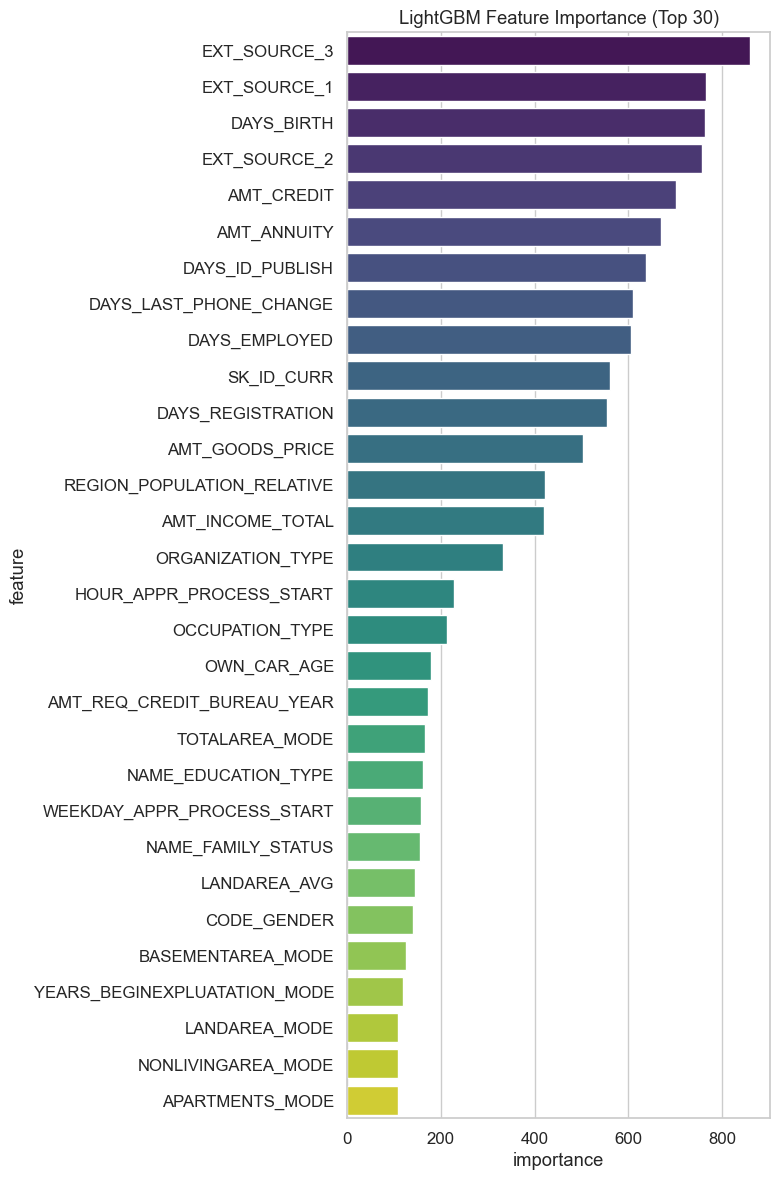

In [16]:
# =========================
# 7. LightGBM feature importance
# =========================

# Get feature importances from the best model
feature_importances = pd.DataFrame(
    {"feature": X_train_lgb_xgb.columns, "importance": best_lgb.feature_importances_}
)

feature_importances.sort_values("importance", ascending=False, inplace=True)

top_n = 30  # show top 30 features
plt.figure(figsize=(8, 12))
sns.barplot(
    data=feature_importances.head(top_n),
    x="importance",
    y="feature",
    palette="viridis",
    hue="feature",
    legend=False,
)
plt.title("LightGBM Feature Importance (Top 30)")
plt.tight_layout()
plt.show()

In [17]:
# =========================
# 8. XGBoost with CV
# =========================

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",  # faster on large data
)

param_dist_xgb = {
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5],
    "reg_lambda": [1.0, 5.0, 10.0],
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_search_xgb.fit(X_train_lgb_xgb, y_train)

print("Best XGBoost params:", random_search_xgb.best_params_)
print("Best CV AUC (XGBoost):", random_search_xgb.best_score_)

best_xgb = random_search_xgb.best_estimator_
y_pred_proba_xgb = best_xgb.predict_proba(X_test_lgb_xgb)[:, 1]
test_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print("XGBoost Test AUC:", test_auc_xgb)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 10.0, 'min_child_weight': 10, 'max_depth': 6, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV AUC (XGBoost): 0.7579664600286996
XGBoost Test AUC: 0.7615840919333563


In [18]:
# =========================
# 9. CatBoost with native categorical features
# =========================

X_cat = X.copy()

# 9.1 Handle missing values similarly
for col in num_cols:
    median_val = X_cat[col].median()
    X_cat[col] = X_cat[col].fillna(median_val)

for col in cat_cols:
    X_cat[col] = X_cat[col].fillna("Missing")


# 9.2 Train/test split for CatBoost
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# CatBoost needs indices of categorical columns
cat_features_indices = [X_train_cat.columns.get_loc(c) for c in cat_cols]

train_pool = Pool(X_train_cat, y_train_cat, cat_features=cat_features_indices)
test_pool = Pool(X_test_cat, y_test_cat, cat_features=cat_features_indices)

# 9.3 Define CatBoost model
cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=100,
    task_type="CPU",  # change to "GPU" if you have GPU support
)

# 9.4 Fit CatBoost
cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# 9.5 Evaluate
y_pred_proba_cat = cat_model.predict_proba(test_pool)[:, 1]
test_auc_cat = roc_auc_score(y_test_cat, y_pred_proba_cat)
print("CatBoost Test AUC:", test_auc_cat)

0:	test: 0.6779205	best: 0.6779205 (0)	total: 543ms	remaining: 9m 2s
100:	test: 0.7518667	best: 0.7518667 (100)	total: 1m 3s	remaining: 9m 29s
200:	test: 0.7569713	best: 0.7569713 (200)	total: 2m 7s	remaining: 8m 25s
300:	test: 0.7594472	best: 0.7594472 (300)	total: 3m 10s	remaining: 7m 23s
400:	test: 0.7609685	best: 0.7609685 (400)	total: 4m 13s	remaining: 6m 18s
500:	test: 0.7618087	best: 0.7618087 (500)	total: 5m 18s	remaining: 5m 16s
600:	test: 0.7621787	best: 0.7621787 (600)	total: 6m 20s	remaining: 4m 12s
700:	test: 0.7626050	best: 0.7626573 (693)	total: 7m 22s	remaining: 3m 8s
800:	test: 0.7628074	best: 0.7628258 (797)	total: 8m 25s	remaining: 2m 5s
900:	test: 0.7630938	best: 0.7630946 (898)	total: 9m 29s	remaining: 1m 2s
999:	test: 0.7632361	best: 0.7632637 (991)	total: 10m 31s	remaining: 0us

bestTest = 0.7632636778
bestIteration = 991

Shrink model to first 992 iterations.
CatBoost Test AUC: 0.7632636777510493


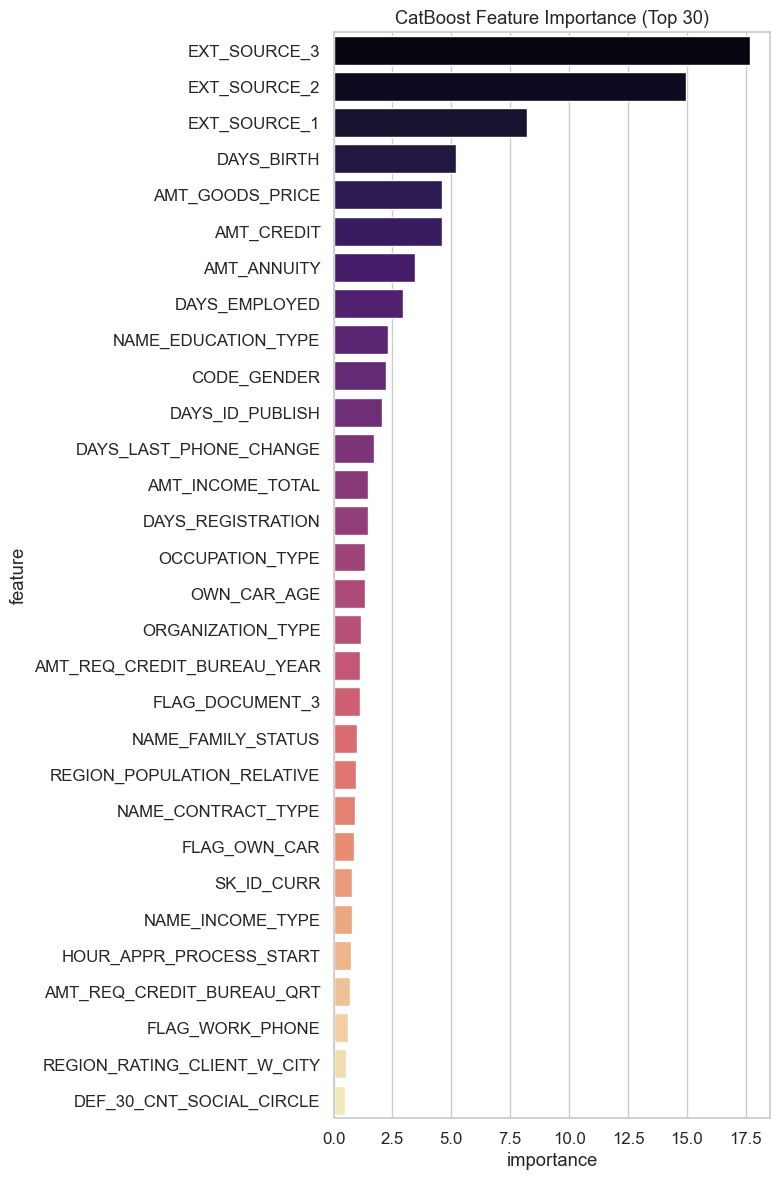

In [19]:
# =========================
# 10. CatBoost feature importance
# =========================

cat_importances = cat_model.get_feature_importance(train_pool)
cat_feat_imp = pd.DataFrame(
    {"feature": X_train_cat.columns, "importance": cat_importances}
).sort_values("importance", ascending=False)

top_n = 30
plt.figure(figsize=(8, 12))
sns.barplot(
    data=cat_feat_imp.head(top_n),
    x="importance",
    y="feature",
    palette="magma",
    hue="feature",
    legend=False,
)
plt.title("CatBoost Feature Importance (Top 30)")
plt.tight_layout()
plt.show()

In [20]:
# =========================
# 11. Model comparison summary
# =========================

results = pd.DataFrame(
    {
        "model": ["LightGBM", "XGBoost", "CatBoost"],
        "test_auc": [test_auc_lgb, test_auc_xgb, test_auc_cat],
    }
)

print(results.sort_values("test_auc", ascending=False))

      model  test_auc
2  CatBoost  0.763264
0  LightGBM  0.762551
1   XGBoost  0.761584


How to push performance further (like on Kaggle):

More feature engineering:
    Ratios (e.g., AMT_CREDIT / AMT_INCOME_TOTAL)
    Nonlinear transformations (e.g., DAYS_BIRTH to age in years)
    Aggregations from other tables (bureau, previous_application, etc.).

More aggressive hyperparameter tuning:
    Use Optuna or a larger RandomizedSearchCV search space.
    Cross‑validation only (no hold‑out) for final model training, then predict on application_test.csv for Kaggle submission.